In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('phishing_email_detection_2026_dataset.csv')
df.head()

,email_id,sender_email,subject,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing
0,1,harrisonsandra@paypal-alert.com,Meeting Reminder,0,1,2,0,227,0
1,2,randyharris@bankverify.net,Urgent Account Verification,1,1,9,7,59,1
2,3,adam13@outlook.com,Suspicious Login Attempt,1,1,8,10,67,1
3,4,kennethfisher@company-secure.com,Suspicious Login Attempt,0,1,9,8,102,1
4,5,wsandoval@paypal-alert.com,Your Password Will Expire,1,0,7,4,96,1


# Dataset Overview

In [3]:
df.describe()

,email_id,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,0.629333,0.512667,5.722667,3.708000,132.559333,0.493333
std,433.157015,0.483144,0.500006,3.002182,3.209819,79.315970,0.500122
min,1.000000,0.000000,0.000000,1.000000,0.000000,20.000000,0.000000
25%,375.750000,0.000000,0.000000,3.000000,1.000000,72.000000,0.000000
50%,750.500000,1.000000,1.000000,5.000000,2.000000,108.000000,0.000000
75%,1125.250000,1.000000,1.000000,8.000000,6.000000,193.000000,1.000000
max,1500.000000,1.000000,1.000000,10.000000,10.000000,300.000000,1.000000


In [4]:
df["spelling_errors"].value_counts()

spelling_errors
2     264
1     254
0     242
4     104
7     100
9      95
6      94
10     92
5      90
3      89
8      76
Name: count, dtype: int64

In [5]:
df.isna().sum()

email_id              0
sender_email          0
subject               0
has_link              0
has_attachment        0
urgency_score         0
spelling_errors       0
email_length_words    0
is_phishing           0
dtype: int64

In [6]:
df["subject"].value_counts()

subject
Claim Your Reward Now          167
Meeting Reminder               163
Suspicious Login Attempt       162
Invoice Attached               162
Weekly Newsletter              153
Bank Account Locked            152
Interview Schedule             141
Project Update                 141
Your Password Will Expire      132
Urgent Account Verification    127
Name: count, dtype: int64

<Axes: xlabel='has_link', ylabel='count'>

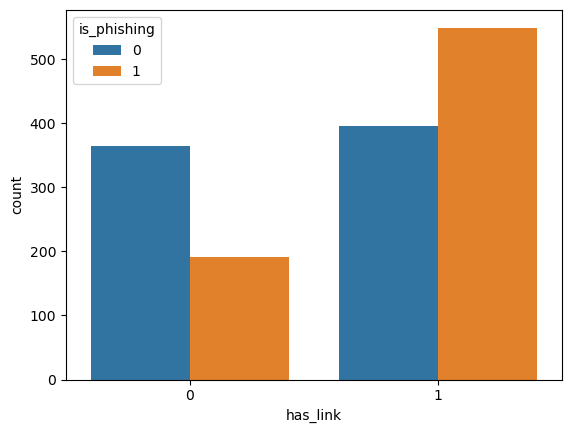

In [7]:

sns.countplot(x = df["has_link"], hue=df["is_phishing"])

<Axes: xlabel='urgency_score', ylabel='count'>

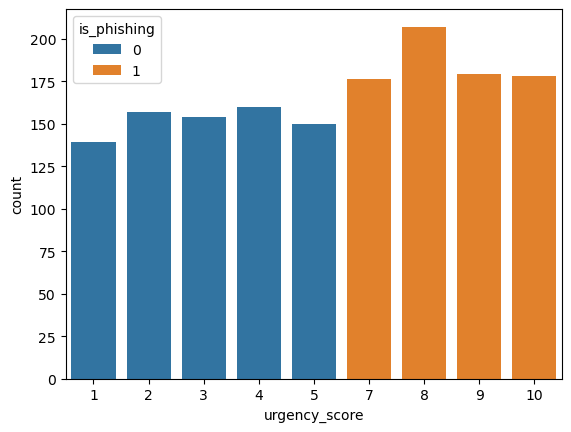

In [8]:
sns.countplot(x = df["urgency_score"], hue=df["is_phishing"])

<Axes: xlabel='spelling_errors', ylabel='count'>

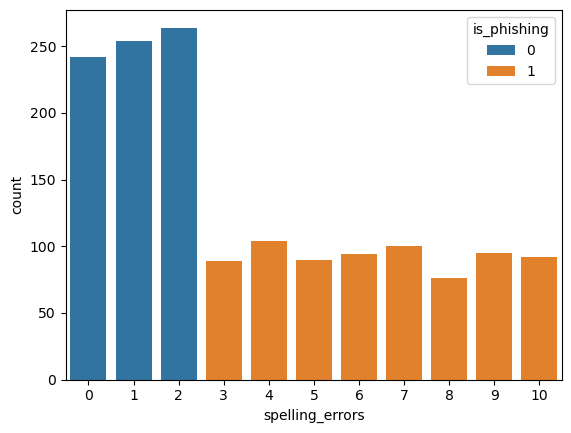

In [9]:
sns.countplot(x = df["spelling_errors"], hue=df["is_phishing"])

<Axes: ylabel='email_length_words'>

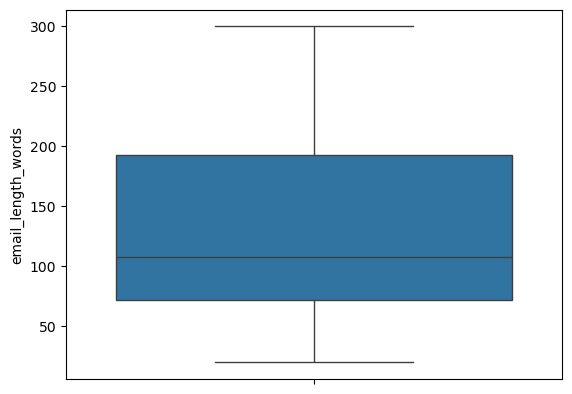

In [10]:
sns.boxplot(df["email_length_words"])

In [11]:
df["email_length_words"].max()

300

<Axes: xlabel='is_phishing', ylabel='email_length_words'>

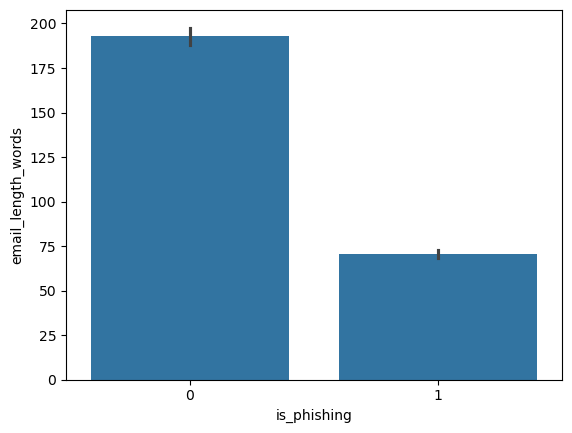

In [12]:
sns.barplot(x = df["is_phishing"], y =df["email_length_words"], )

In [13]:
df.head()

,email_id,sender_email,subject,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing
0,1,harrisonsandra@paypal-alert.com,Meeting Reminder,0,1,2,0,227,0
1,2,randyharris@bankverify.net,Urgent Account Verification,1,1,9,7,59,1
2,3,adam13@outlook.com,Suspicious Login Attempt,1,1,8,10,67,1
3,4,kennethfisher@company-secure.com,Suspicious Login Attempt,0,1,9,8,102,1
4,5,wsandoval@paypal-alert.com,Your Password Will Expire,1,0,7,4,96,1


# Data Cleaning and Feature Engineering

In [14]:
df["Extension"] = df["sender_email"].str.split('.').str[-1]

In [15]:
df.head()

,email_id,sender_email,subject,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing,Extension
0,1,harrisonsandra@paypal-alert.com,Meeting Reminder,0,1,2,0,227,0,com
1,2,randyharris@bankverify.net,Urgent Account Verification,1,1,9,7,59,1,net
2,3,adam13@outlook.com,Suspicious Login Attempt,1,1,8,10,67,1,com
3,4,kennethfisher@company-secure.com,Suspicious Login Attempt,0,1,9,8,102,1,com
4,5,wsandoval@paypal-alert.com,Your Password Will Expire,1,0,7,4,96,1,com


<Axes: xlabel='Extension', ylabel='Count'>

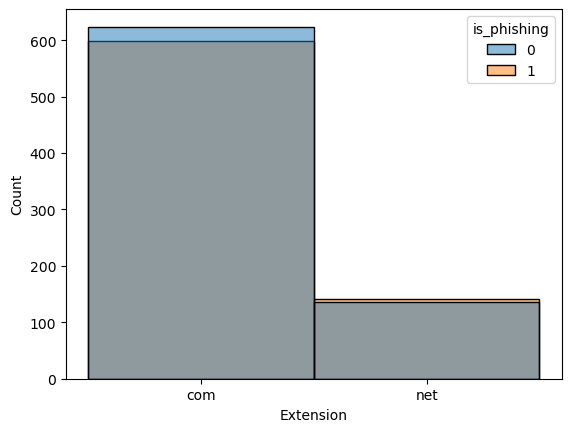

In [16]:
sns.histplot(x = df["Extension"], hue = df["is_phishing"])

In [17]:
df["Extension"].value_counts()

Extension
com    1223
net     277
Name: count, dtype: int64

<Axes: xlabel='Extension', ylabel='is_phishing'>

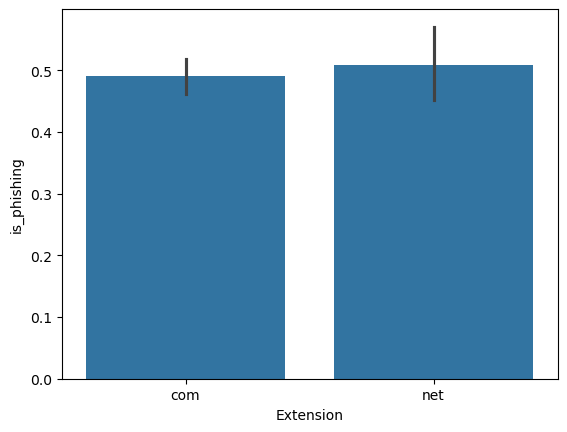

In [18]:
sns.barplot(x = df["Extension"], y = df["is_phishing"])

<Axes: xlabel='is_phishing', ylabel='subject'>

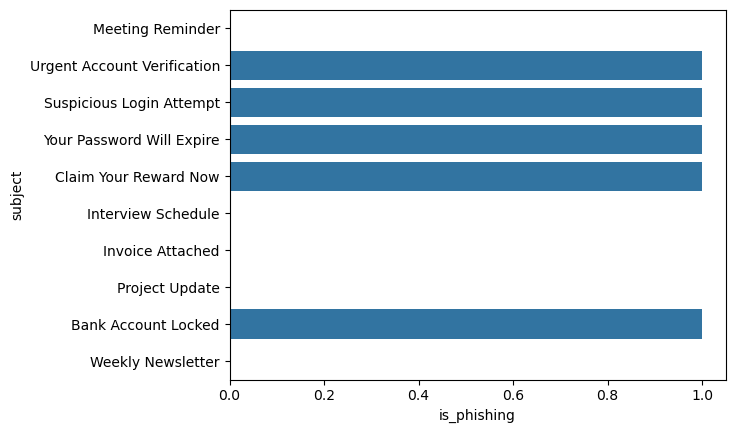

In [19]:
sns.barplot(y = df["subject"], x = df["is_phishing"])

In [20]:
df.head()

,email_id,sender_email,subject,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing,Extension
0,1,harrisonsandra@paypal-alert.com,Meeting Reminder,0,1,2,0,227,0,com
1,2,randyharris@bankverify.net,Urgent Account Verification,1,1,9,7,59,1,net
2,3,adam13@outlook.com,Suspicious Login Attempt,1,1,8,10,67,1,com
3,4,kennethfisher@company-secure.com,Suspicious Login Attempt,0,1,9,8,102,1,com
4,5,wsandoval@paypal-alert.com,Your Password Will Expire,1,0,7,4,96,1,com


In [21]:
df["Domain"] = df["sender_email"].str.split("@").str[1].str.split('.').str[0]
df.head()

,email_id,sender_email,subject,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing,Extension,Domain
0,1,harrisonsandra@paypal-alert.com,Meeting Reminder,0,1,2,0,227,0,com,paypal-alert
1,2,randyharris@bankverify.net,Urgent Account Verification,1,1,9,7,59,1,net,bankverify
2,3,adam13@outlook.com,Suspicious Login Attempt,1,1,8,10,67,1,com,outlook
3,4,kennethfisher@company-secure.com,Suspicious Login Attempt,0,1,9,8,102,1,com,company-secure
4,5,wsandoval@paypal-alert.com,Your Password Will Expire,1,0,7,4,96,1,com,paypal-alert


<Axes: xlabel='is_phishing', ylabel='Domain'>

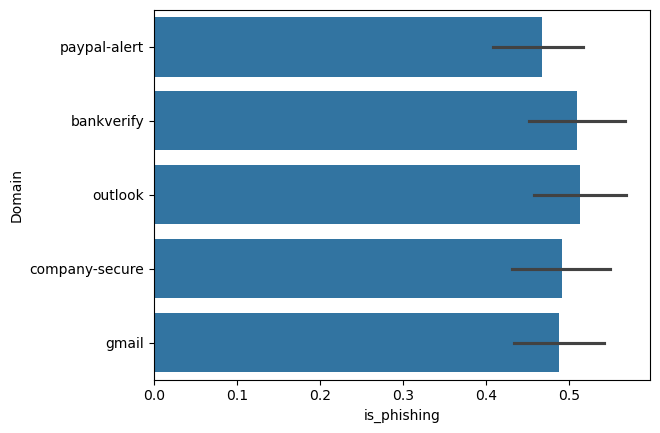

In [22]:
sns.barplot(y = df["Domain"], x = df["is_phishing"])

<Axes: xlabel='has_attachment', ylabel='count'>

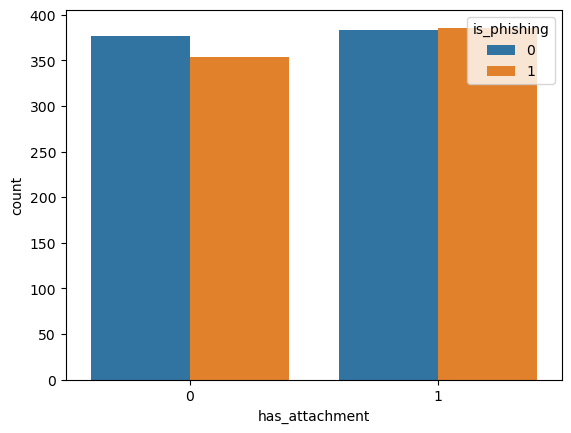

In [27]:
sns.countplot(x = df["has_attachment"], hue = df["is_phishing"])

<Axes: xlabel='count', ylabel='subject'>

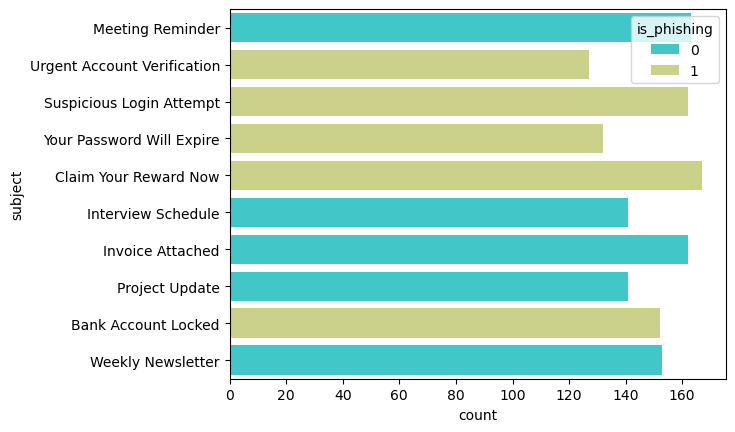

In [30]:
sns.countplot(y = df["subject"], hue = df["is_phishing"], palette="rainbow")

# Correlation Analysis

<Axes: >

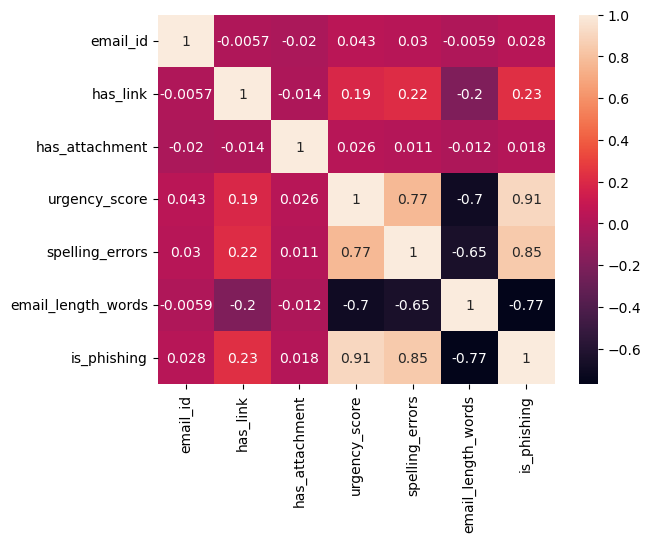

In [47]:
sns.heatmap(df.corr(numeric_only=True), annot =True)

 # Encoding Categorical Variables & Standardization

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   email_id            1500 non-null   int64 
 1   sender_email        1500 non-null   object
 2   subject             1500 non-null   object
 3   has_link            1500 non-null   int64 
 4   has_attachment      1500 non-null   int64 
 5   urgency_score       1500 non-null   int64 
 6   spelling_errors     1500 non-null   int64 
 7   email_length_words  1500 non-null   int64 
 8   is_phishing         1500 non-null   int64 
 9   Extension           1500 non-null   object
 10  Domain              1500 non-null   object
dtypes: int64(7), object(4)
memory usage: 129.0+ KB


In [61]:
df = df.drop(columns=["email_id", "sender_email"] , inplace =True)
#i run this 2nd time so error came

KeyError: "['email_id', 'sender_email'] not found in axis"

In [62]:
df

,subject,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing,Extension,Domain
0,Meeting Reminder,0,1,2,0,227,0,com,paypal-alert
1,Urgent Account Verification,1,1,9,7,59,1,net,bankverify
2,Suspicious Login Attempt,1,1,8,10,67,1,com,outlook
3,Suspicious Login Attempt,0,1,9,8,102,1,com,company-secure
4,Your Password Will Expire,1,0,7,4,96,1,com,paypal-alert
...,...,...,...,...,...,...,...,...,...
1495,Claim Your Reward Now,1,1,8,7,113,1,com,gmail
1496,Urgent Account Verification,1,0,8,5,50,1,com,gmail
1497,Suspicious Login Attempt,0,0,8,10,82,1,com,outlook
1498,Suspicious Login Attempt,1,0,7,9,36,1,com,paypal-alert


In [64]:
df["subject"].unique()

array(['Meeting Reminder', 'Urgent Account Verification',
       'Suspicious Login Attempt', 'Your Password Will Expire',
       'Claim Your Reward Now', 'Interview Schedule', 'Invoice Attached',
       'Project Update', 'Bank Account Locked', 'Weekly Newsletter'],
      dtype=object)

In [65]:
df["subject"].nunique()

10

In [70]:
df = pd.get_dummies(
    df,
    columns = [ "subject", "Domain", "Extension"],
    drop_first = True
)
df

#i run this 2nd time so error came

KeyError: "None of [Index(['subject', 'Domain', 'Extension'], dtype='object')] are in the [columns]"

In [83]:
df

,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing,subject_Claim Your Reward Now,subject_Interview Schedule,subject_Invoice Attached,subject_Meeting Reminder,subject_Project Update,subject_Suspicious Login Attempt,subject_Urgent Account Verification,subject_Weekly Newsletter,subject_Your Password Will Expire,Domain_company-secure,Domain_gmail,Domain_outlook,Domain_paypal-alert,Extension_net
0,0,1,-1,-1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
1,1,1,1,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
2,1,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0
3,0,1,1,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0
4,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0
1496,1,0,0,0,-1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0
1497,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0
1498,1,0,0,1,-1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0


In [74]:
df.astype(int)

,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing,subject_Claim Your Reward Now,subject_Interview Schedule,subject_Invoice Attached,subject_Meeting Reminder,subject_Project Update,subject_Suspicious Login Attempt,subject_Urgent Account Verification,subject_Weekly Newsletter,subject_Your Password Will Expire,Domain_company-secure,Domain_gmail,Domain_outlook,Domain_paypal-alert,Extension_net
0,0,1,2,0,227,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
1,1,1,9,7,59,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
2,1,1,8,10,67,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0
3,0,1,9,8,102,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0
4,1,0,7,4,96,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1,1,8,7,113,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0
1496,1,0,8,5,50,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0
1497,0,0,8,10,82,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0
1498,1,0,7,9,36,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0


In [84]:
df[["email_length_words", "urgency_score", "spelling_errors"]] = ss.fit_transform(df[["email_length_words", "urgency_score", "spelling_errors"]])


In [81]:
df

,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing,subject_Claim Your Reward Now,subject_Interview Schedule,subject_Invoice Attached,subject_Meeting Reminder,subject_Project Update,subject_Suspicious Login Attempt,subject_Urgent Account Verification,subject_Weekly Newsletter,subject_Your Password Will Expire,Domain_company-secure,Domain_gmail,Domain_outlook,Domain_paypal-alert,Extension_net
0,0,1,-1,-1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
1,1,1,1,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
2,1,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0
3,0,1,1,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0
4,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0
1496,1,0,0,0,-1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0
1497,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0
1498,1,0,0,1,-1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0


In [86]:
duplicate = pd.read_csv("phishing_email_detection_2026_dataset.csv")

df[["email_length_words", "urgency_score", "spelling_errors"]] = duplicate[
    ["email_length_words", "urgency_score", "spelling_errors"]]

In [87]:
df

,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing,subject_Claim Your Reward Now,subject_Interview Schedule,subject_Invoice Attached,subject_Meeting Reminder,subject_Project Update,subject_Suspicious Login Attempt,subject_Urgent Account Verification,subject_Weekly Newsletter,subject_Your Password Will Expire,Domain_company-secure,Domain_gmail,Domain_outlook,Domain_paypal-alert,Extension_net
0,0,1,2,0,227,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
1,1,1,9,7,59,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
2,1,1,8,10,67,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0
3,0,1,9,8,102,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0
4,1,0,7,4,96,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1,1,8,7,113,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0
1496,1,0,8,5,50,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0
1497,0,0,8,10,82,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0
1498,1,0,7,9,36,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0


In [88]:
df[["email_length_words", "urgency_score", "spelling_errors"]] = ss.fit_transform(df[["email_length_words", "urgency_score", "spelling_errors"]])

# Final Dataset

In [89]:
df

,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing,subject_Claim Your Reward Now,subject_Interview Schedule,subject_Invoice Attached,subject_Meeting Reminder,subject_Project Update,subject_Suspicious Login Attempt,subject_Urgent Account Verification,subject_Weekly Newsletter,subject_Your Password Will Expire,Domain_company-secure,Domain_gmail,Domain_outlook,Domain_paypal-alert,Extension_net
0,0,1,-1.240401,-1.155591,1.191086,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
1,1,1,1.092015,1.025945,-0.927731,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
2,1,1,0.758812,1.960889,-0.826835,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0
3,0,1,1.092015,1.337593,-0.385414,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0
4,1,0,0.425610,0.091001,-0.461087,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1,1,0.758812,1.025945,-0.246682,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0
1496,1,0,0.758812,0.402649,-1.041239,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0
1497,0,0,0.758812,1.960889,-0.637655,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0
1498,1,0,0.425610,1.649241,-1.217807,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0


In [90]:
df.to_csv("processed_email_dataset.csv")